# True Parameters at 1 PA Model

```python
m1 = 1e6
m2 = 10
a = 0.96
e0 = 0.5
xI0 = 1.0
dist = 0.4

qS = xp.pi/4
phiS = 1.0
qK = 1
phiK = xp.pi/3

Phi_phi0 = 0.9
Phi_theta0 = 0.5
Phi_r0 = 0.4

dt = 10.0
T = 0.5

chi2 = 0.0

dev_0_p = 0.0
dev_0_e = 0.0
dev_1_p = 0.0
dev_1_e = 0.0
dev_2_p = 0.0
dev_2_e = 0.0

evolve_1PA = True
evolve_primary = False
evolve_2PA = False
deviation_included = True

p0 = 7.0

best_fit = [1.38157230e+01, 1.00015303e+01, 9.60119711e-01, 6.99924649e+00,4.99961881e-01, 7.85400398e-01, 9.99641356e-01, 8.99421437e-01,3.99348944e-01, 9.96110659e-06, 2.81855996e-05]

In [5]:
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
from scipy.stats import chi2


from itertools import product
import os
import h5py
from tqdm import tqdm
import pandas as pd

#few utils
from few.utils.utility import get_p_at_t
from few.utils.constants import MTSUN_SI
from few.utils.geodesic import get_fundamental_frequencies
#few trajectory
from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode.flux import SuperKludgeFlux
#few waveform
from few.waveform import FastKerrEccentricEquatorialFlux, GenerateEMRIWaveform
from few.waveform.waveform import SuperKludgeWaveform
from few.utils.constants import YRSID_SI

#sef imports
from stableemrifisher.fisher import StableEMRIFisher
from stableemrifisher.utils import generate_PSD, padding, inner_product
from stableemrifisher.fisher.derivatives import derivative
from stableemrifisher.fisher.stablederivative import StableEMRIDerivative
from stableemrifisher.noise import sensitivity_LWA

#lisa-on-gpu import
from fastlisaresponse import ResponseWrapper  # Response function 

#LISAanalysistools imports
from lisatools.detector import ESAOrbits, EqualArmlengthOrbits #ESAOrbits correspond to esa-trailing-orbits.h5, EqualArmlengthOrbits are equalarmlength-orbits.h5
from lisatools.sensitivity import get_sensitivity, A1TDISens, E1TDISens, T1TDISens
from lisatools.sensitivity import get_sensitivity,CornishLISASens

use_gpu = True
from parismc.sampler import SamplerConfig
from parismc.sampler import Sampler

from smt.sampling_methods import LHS

if not use_gpu:
    
    import few
    
    #tune few configuration
    cfg_set = few.get_config_setter(reset=True)
    
    cfg_set.enable_backends("cpu")
    cfg_set.set_log_level("info");
else:
    pass #let the backend decide for itself

In [6]:
#waveform class setup
waveform_class = SuperKludgeWaveform
max_step_days = 10.0 #max trajectory step size in days
inspiral_kwargs = {
    "err":1e-11, #default = 1e-11
    "max_step_size":max_step_days*24*60*60, #in seconds
}
sum_kwargs = {
    "pad_output": True, # True if expecting waveforms smaller than LISA observation window.
}

waveform_class_kwargs = dict(inspiral_kwargs=inspiral_kwargs,
                              mode_selector_kwargs=dict(mode_selection_threshold=1e-5),
                              sum_kwargs=sum_kwargs,
                              use_gpu=use_gpu)

waveform_generator = GenerateEMRIWaveform
waveform_generator_kwargs = dict(return_list=False)


In [7]:
if(use_gpu):
    xp=cp
else:
    xp=np

best_fit = [1.38157230e+01, 1.00015303e+01, 9.60119711e-01,
             6.99924649e+00,4.99961881e-01, 7.85400398e-01, 9.99641356e-01, 8.99421437e-01,3.99348944e-01, 9.96110659e-06, 2.81855996e-05]
#logm1_, m2_, a_, p0_, e0_,qS_,phiS_,Phi_phi0_,Phi_r0_,dev0p_,dev0e_ = params[i]
logm1 = best_fit[0]
m1= np.exp(logm1)
m2 = best_fit[1]
a = best_fit[2]
p0= best_fit[3]
e0 = best_fit[4]
xI0 = 1.0
dist = 0.4
qS = best_fit[5]
phiS = best_fit[6]
qK = 1 
phiK = np.pi/3
Phi_phi0 = best_fit[7]
Phi_theta0 =0.5
Phi_r0 = best_fit[8]

dt = 10.0
T = 0.5

chi2 = 0.0

dev_0_p=best_fit[9]
dev_0_e=best_fit[10]
dev_1_p=0.0
dev_1_e=0.0
dev_2_p=0.0
dev_2_e=0.0
evolve_1PA = False
evolve_primary = False
evolve_2PA = False
deviation_included=True


print(use_gpu)

pars_list_com = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,\
             chi2,evolve_1PA,evolve_primary,evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]

add_param_args={"chi2":chi2,"evolve_1PA":evolve_1PA,"evolve_primary":evolve_primary,"evolve_2PA":evolve_2PA,"deviation_included":deviation_included,"dev0p":dev_0_p,
"dev0e":dev_0_e,"dev1p":dev_1_p,"dev1e":dev_1_e,"dev2p":dev_2_p,"dev2e":dev_2_e}

param_names = ['m1','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0','dev0p','dev0e']
add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]

emri_kwargs = {"T":T, "dt":dt}

param_names_com = ['m1','m2','a','p0','e0','xI0','dist','qS','phiS','qK','phiK','Phi_phi0','Phi_theta0','Phi_r0',"chi2",
               "evolve_1PA","evolve_primary","evolve_2PA","deviation_included","dev0p","dev0e","dev1p","dev1e","dev2p","dev2e"]

True


In [8]:
der_order = 8
Ndelta=16
sef = StableEMRIFisher(waveform_class=waveform_class, 
                       waveform_class_kwargs=waveform_class_kwargs,
                       waveform_generator=waveform_generator,
                       waveform_generator_kwargs=waveform_generator_kwargs,
                       stats_for_nerds = True, use_gpu = use_gpu,
                       deriv_type='stable',
                       noise_model=get_sensitivity,
                       noise_kwargs={'sens_fn':CornishLISASens,'return_type':'PSD'},
                       channels=["A","E"],
                       T = T, dt = dt,
                       stability_plot = False,
                       der_order = der_order, Ndelta = Ndelta,
                       plunge_check=True, return_derivatives=False
                       )
                   

SNR = sef.SNRcalc_SEF(*pars_list_com,**emri_kwargs,use_gpu=use_gpu)
print("SNR: ", SNR)

waveform shape:  (2, 1577908)
wave ndim: 2
Computing SNR for parameters: (np.float64(1000212.4646031334), 10.0015303, 0.960119711, 6.99924649, 0.499961881, 1.0, 0.4, 0.785400398, 0.999641356, 1, 1.0471975511965976, 0.899421437, 0.5, 0.399348944, 0.0, False, False, False, True, 9.96110659e-06, 2.81855996e-05, 0.0, 0.0, 0.0, 0.0)
SNR:  79.81344158257791


Body is not plunging, Fisher should be stable.
waveform shape:  (2, 1577908)
wave ndim: 2
Computing SNR for parameters: (np.float64(1000212.4646031334), 10.0015303, 0.960119711, 6.99924649, 0.499961881, 1.0, 0.4, 0.785400398, 0.999641356, 1, 1.0471975511965976, 0.899421437, 0.5, 0.399348944, 0.0, False, False, False, True, 9.96110659e-06, 2.81855996e-05, 0.0, 0.0, 0.0, 0.0)
Waveform Generated. SNR: 79.81344158257791
calculating stable deltas...
Gamma_ii for m1: 905.8243351993539
Gamma_ii for m1: 905.8243352079219
Gamma_ii for m1: 905.8243352034806
Gamma_ii for m1: 905.8243351793142
Gamma_ii for m1: 905.8243352082847
Gamma_ii for m1: 905.8243352159849
Gamma_ii for m1: 905.8243352530117
Gamma_ii for m1: 905.8243353759389
Gamma_ii for m1: 905.8243354034265
Gamma_ii for m1: 905.8243360616817
Gamma_ii for m1: 905.8243279334381
Gamma_ii for m1: 905.8243206724354
Gamma_ii for m1: 905.8243146714874
Gamma_ii for m1: 905.8243553696706
Gamma_ii for m1: 905.8243690133605
Gamma_ii for m1: 905.82454

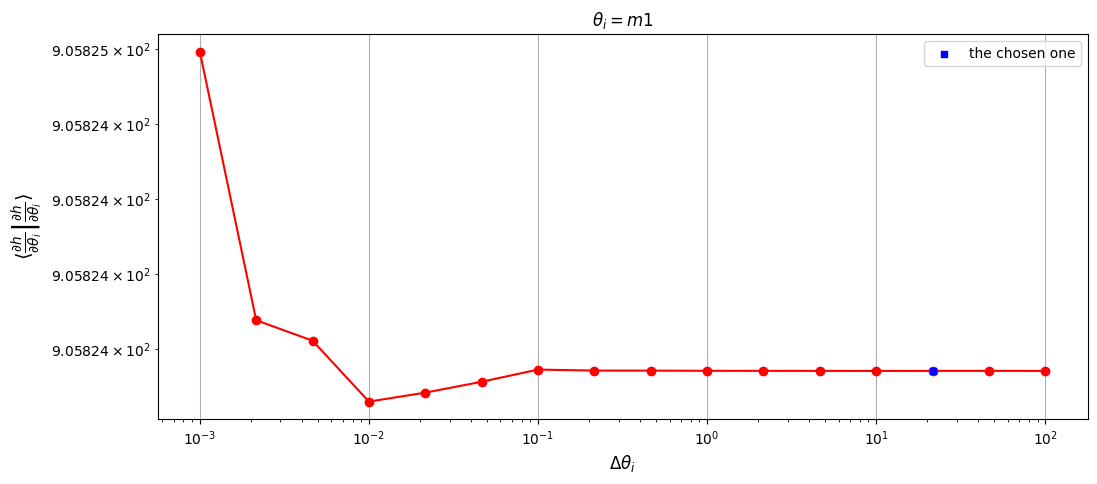

Gamma_ii for m2: 120404772353.76938
Gamma_ii for m2: 120404772359.66661
Gamma_ii for m2: 120404772340.86899
Gamma_ii for m2: 120404772356.50075
Gamma_ii for m2: 120404772381.38141
Gamma_ii for m2: 120404772312.36658
Gamma_ii for m2: 120404772464.506
Gamma_ii for m2: 120404771957.35822
Gamma_ii for m2: 120404772260.37968
Gamma_ii for m2: 120404774870.73845
Gamma_ii for m2: 120404767761.42043
Gamma_ii for m2: 120404776902.65427
Gamma_ii for m2: 120404779106.06636
Gamma_ii for m2: 120404761751.7251
Gamma_ii for m2: 120404826191.92183
Gamma_ii for m2: 120404728953.2998
[np.float64(4.897839130535599e-11), np.float64(1.5612024602685607e-10), np.float64(1.298267447179864e-10), np.float64(2.066418175845459e-10), np.float64(5.731901669472311e-10), np.float64(1.2635663557315645e-09), np.float64(4.212023934995521e-09), np.float64(2.5166898572833645e-09), np.float64(2.167986084813339e-08), np.float64(5.9045153741491434e-08), np.float64(7.592085693022756e-08), np.float64(1.8300038507401707e-08), np

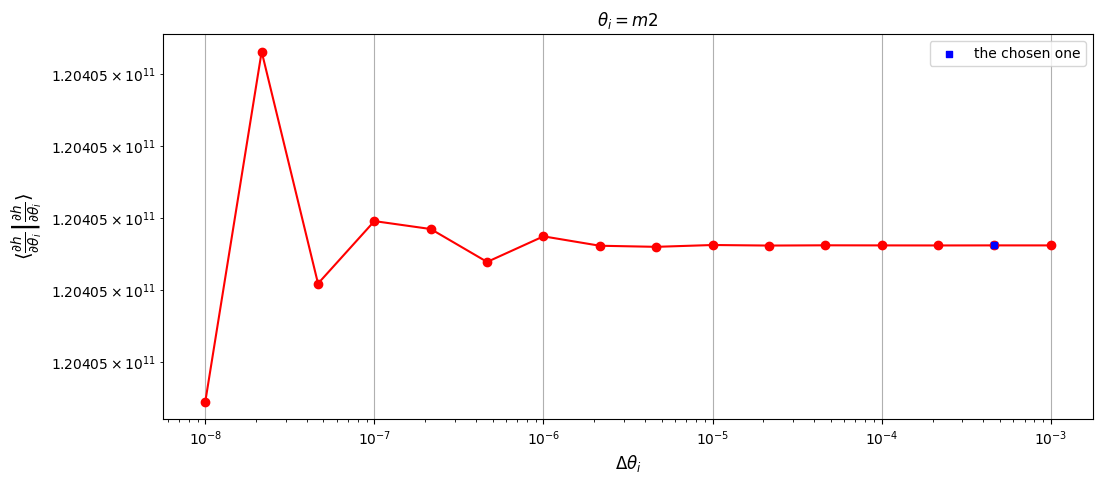

Gamma_ii for a: 7166624233352.198
Gamma_ii for a: 7166649044685.678
Gamma_ii for a: 7166675281707.269
Gamma_ii for a: 7166194442243.932
Gamma_ii for a: 7166855595689.905
Gamma_ii for a: 7167313981256.891
Gamma_ii for a: 7165008627757.314
Gamma_ii for a: 7168929979567.565
Gamma_ii for a: 7183114867388.308
Gamma_ii for a: 7158747568106.042
Gamma_ii for a: 7324847314920.196
Gamma_ii for a: 7511615742296.161
Gamma_ii for a: 7563531863941.4
Gamma_ii for a: 7940546219532.931
Gamma_ii for a: 6186805736590.996
Gamma_ii for a: 3131612139566.0386
[np.float64(3.4620550448037727e-06), np.float64(3.6609753560049735e-06), np.float64(6.709829983155607e-05), np.float64(9.225153725313591e-05), np.float64(6.395500018334164e-05), np.float64(0.0003217516711208427), np.float64(0.0005469926225290759), np.float64(0.0019747544181901184), np.float64(0.003403849493286767), np.float64(0.022676206024912063), np.float64(0.02486394855427911), np.float64(0.006864005147217753), np.float64(0.047479650035171836), np.fl

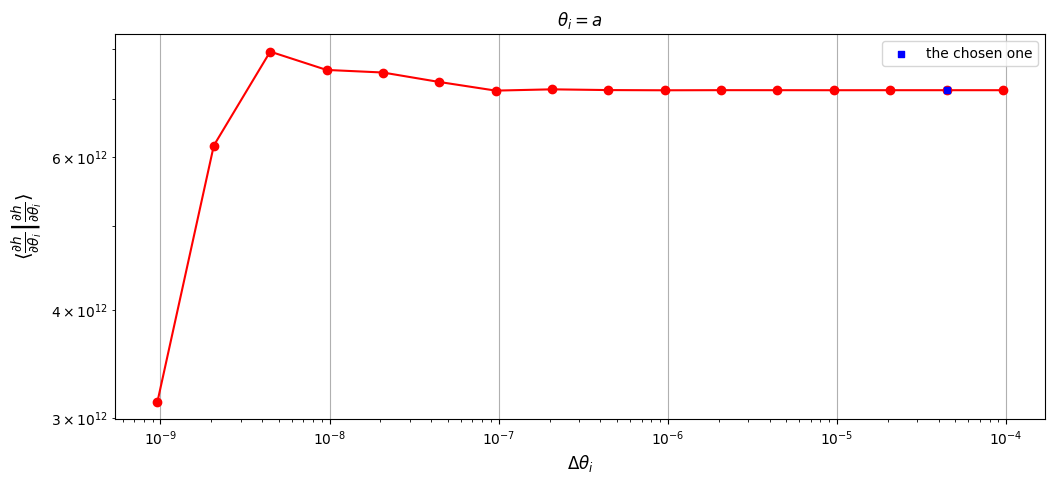

Gamma_ii for p0: 40283118076964.49
Gamma_ii for p0: 40283117705109.65
Gamma_ii for p0: 40283117485080.7
Gamma_ii for p0: 40283112326142.945
Gamma_ii for p0: 40283119147596.01
Gamma_ii for p0: 40283149538082.05
Gamma_ii for p0: 40283109767846.086
Gamma_ii for p0: 40283020766081.336
Gamma_ii for p0: 40282760869001.52
Gamma_ii for p0: 40282847871105.125
Gamma_ii for p0: 40283198892050.94
Gamma_ii for p0: 40284112606108.81
Gamma_ii for p0: 40288097402679.31
Gamma_ii for p0: 40279376880760.4
Gamma_ii for p0: 40263766565930.05
Gamma_ii for p0: 40300181403751.01
[np.float64(9.231034362140065e-09), np.float64(5.462063490840552e-09), np.float64(1.280670102162005e-07), np.float64(1.693377575233542e-07), np.float64(7.544217963973391e-07), np.float64(9.87268266778203e-07), np.float64(2.2094113861724165e-06), np.float64(6.451818947010074e-06), np.float64(2.159780358130267e-06), np.float64(8.71382997048347e-06), np.float64(2.268174718924903e-05), np.float64(9.89075391342505e-05), np.float64(0.000216

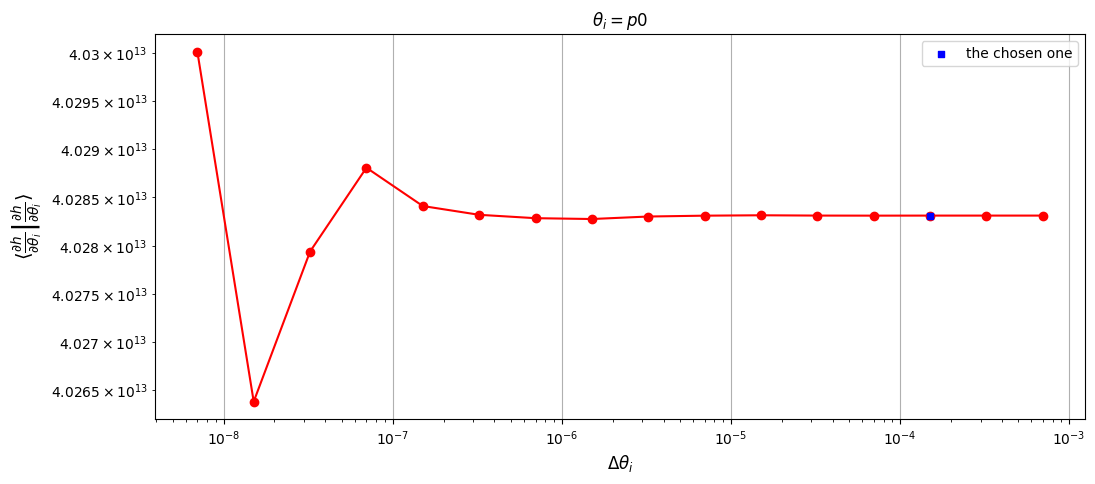

Gamma_ii for e0: 1076400411510877.9
Gamma_ii for e0: 1076400501384432.2
Gamma_ii for e0: 1076400377061848.8
Gamma_ii for e0: 1076400640548067.9
Gamma_ii for e0: 1076401262364268.9
Gamma_ii for e0: 1076400603725698.8
Gamma_ii for e0: 1076401130732400.2
Gamma_ii for e0: 1076395190960125.8
Gamma_ii for e0: 1076398410856649.4
Gamma_ii for e0: 1076428825246876.1
Gamma_ii for e0: 1076351778458916.2
Gamma_ii for e0: 1076377718611183.2
Gamma_ii for e0: 1076261764005728.2
Gamma_ii for e0: 1075647205767020.1
Gamma_ii for e0: 1074301754415796.6
Gamma_ii for e0: 1078258323392864.5
[np.float64(8.349453039032171e-08), np.float64(1.1549845777586211e-07), np.float64(2.447845246458061e-07), np.float64(5.776806686701645e-07), np.float64(6.11889818572456e-07), np.float64(4.896006576483401e-07), np.float64(5.518207740413469e-06), np.float64(2.991361275851803e-06), np.float64(2.8254901312006896e-05), np.float64(7.15814192922949e-05), np.float64(2.409948832875301e-05), np.float64(0.0001077382931671099), np.

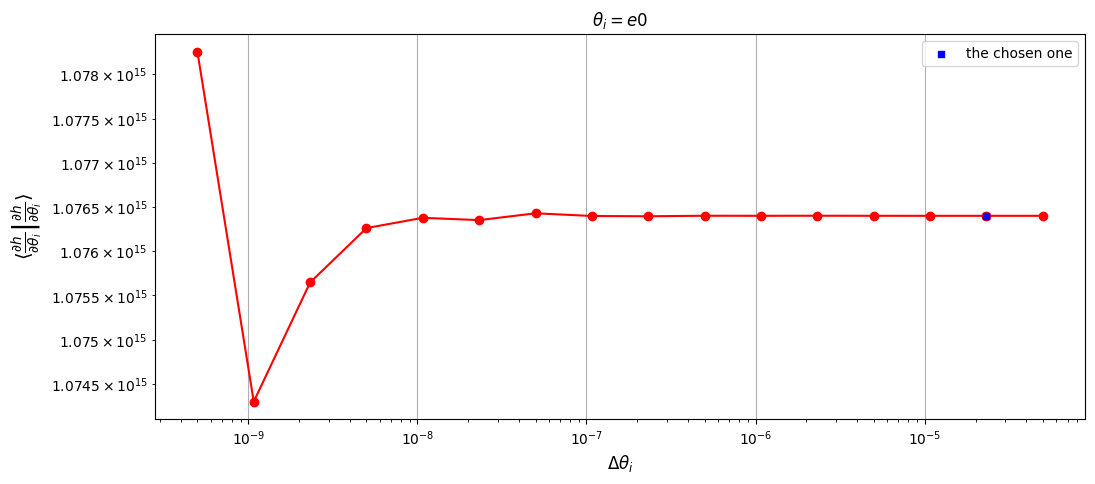

Gamma_ii for qS: 19766.529408991373
Gamma_ii for qS: 19766.529435422428
Gamma_ii for qS: 19766.529435480374
Gamma_ii for qS: 19766.52943548051
Gamma_ii for qS: 19766.52943548048
Gamma_ii for qS: 19766.52943547973
Gamma_ii for qS: 19766.529435480774
Gamma_ii for qS: 19766.529435480155
Gamma_ii for qS: 19766.529435484234
Gamma_ii for qS: 19766.529435465887
Gamma_ii for qS: 19766.52943545709
Gamma_ii for qS: 19766.529435486766
Gamma_ii for qS: 19766.529435471824
Gamma_ii for qS: 19766.52943527639
Gamma_ii for qS: 19766.529434407254
Gamma_ii for qS: 19766.529435278324
[np.float64(1.337162135985409e-09), np.float64(2.931507355830803e-12), np.float64(6.80975465631209e-15), np.float64(1.4723793851485622e-15), np.float64(3.791376916757691e-14), np.float64(5.282161044220388e-14), np.float64(3.128806193440746e-14), np.float64(2.063171613439031e-13), np.float64(9.2815115491371e-13), np.float64(4.450266691616795e-13), np.float64(1.5012748305816252e-12), np.float64(7.55882766850974e-13), np.float64

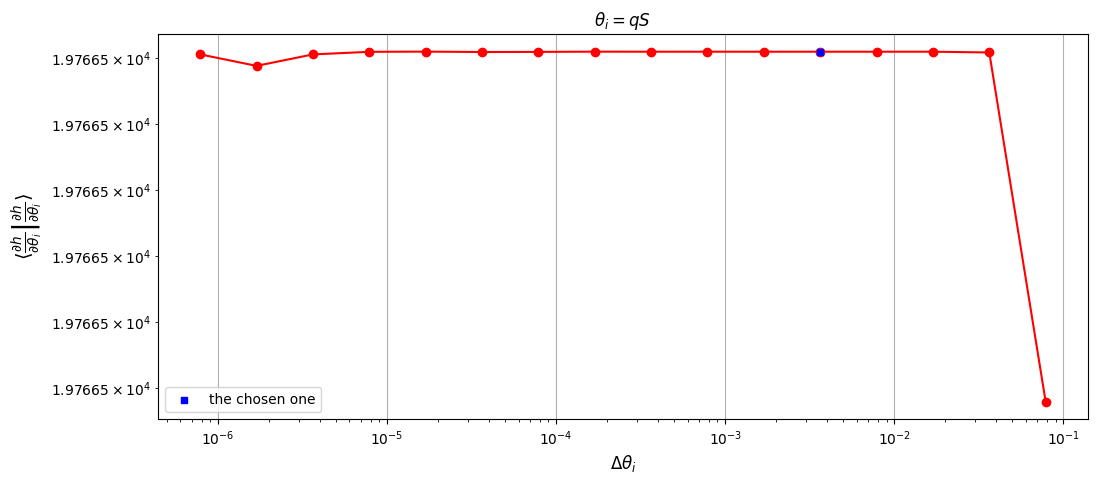

Gamma_ii for phiS: 377225.1120593784
Gamma_ii for phiS: 377225.1120542986
Gamma_ii for phiS: 377225.1120542874
Gamma_ii for phiS: 377225.1120542874
Gamma_ii for phiS: 377225.1120542874
Gamma_ii for phiS: 377225.1120542874
Gamma_ii for phiS: 377225.1120542874
Gamma_ii for phiS: 377225.11205428746
Gamma_ii for phiS: 377225.11205428746
Gamma_ii for phiS: 377225.1120542874
Gamma_ii for phiS: 377225.1120542876
Gamma_ii for phiS: 377225.11205428763
Gamma_ii for phiS: 377225.11205428356
Gamma_ii for phiS: 377225.11205429165
Gamma_ii for phiS: 377225.11205428786
Gamma_ii for phiS: 377225.11205426167
[np.float64(1.3466337773525563e-11), np.float64(2.9626529460152685e-14), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(1.543048409382952e-16), np.float64(0.0), np.float64(1.5430484093829522e-16), np.float64(4.629145228148854e-16), np.float64(1.5430484093829513e-16), np.float64(1.0801338865680776e-14), np.float64(2.1448372890422795e-14), np.float64(1.0029814660989177

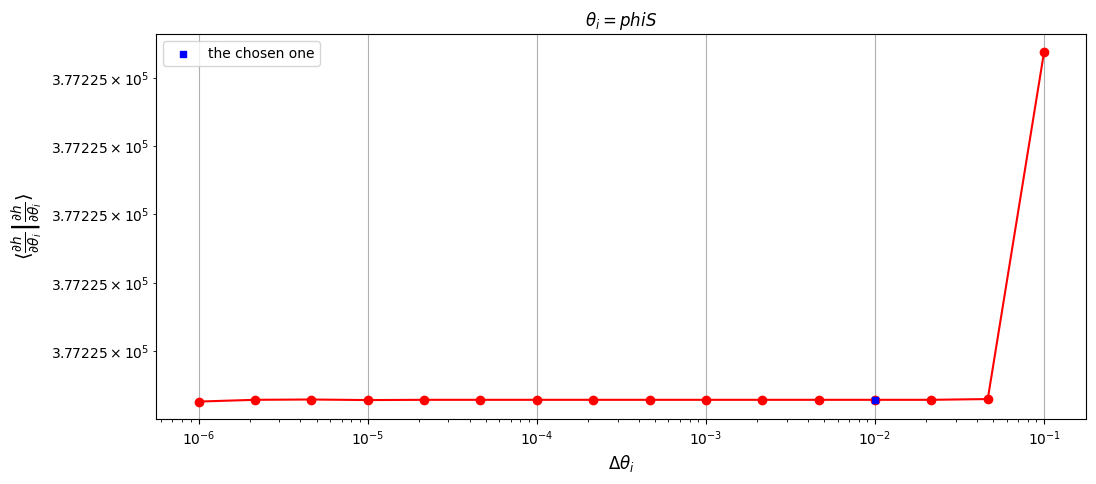

Gamma_ii for dev0p: 5214033101032.093
Gamma_ii for dev0p: 5213599027177.211
Gamma_ii for dev0p: 5214024953707.142
Gamma_ii for dev0p: 5214849285640.239
Gamma_ii for dev0p: 5216258068980.605
Gamma_ii for dev0p: 5217323376171.291
Gamma_ii for dev0p: 5203496220679.343
Gamma_ii for dev0p: 5251415073574.956
Gamma_ii for dev0p: 5194911231174.612
Gamma_ii for dev0p: 5130444821944.833
Gamma_ii for dev0p: 5107328347766.427
Gamma_ii for dev0p: 4416011193189.874
Gamma_ii for dev0p: 5659216787155.862
Gamma_ii for dev0p: 3688120486852.739
Gamma_ii for dev0p: 6927878325754.655
Gamma_ii for dev0p: 4319311310993.4316
[np.float64(8.325800519355546e-05), np.float64(8.16886251431982e-05), np.float64(0.000158073970683594), np.float64(0.00027007546822573606), np.float64(0.0002041865366350586), np.float64(0.002657281740111082), np.float64(0.009124941034796554), np.float64(0.010876767645472888), np.float64(0.012565461956443296), np.float64(0.00452613824770356), np.float64(0.15654787189911643), np.float64(0.2

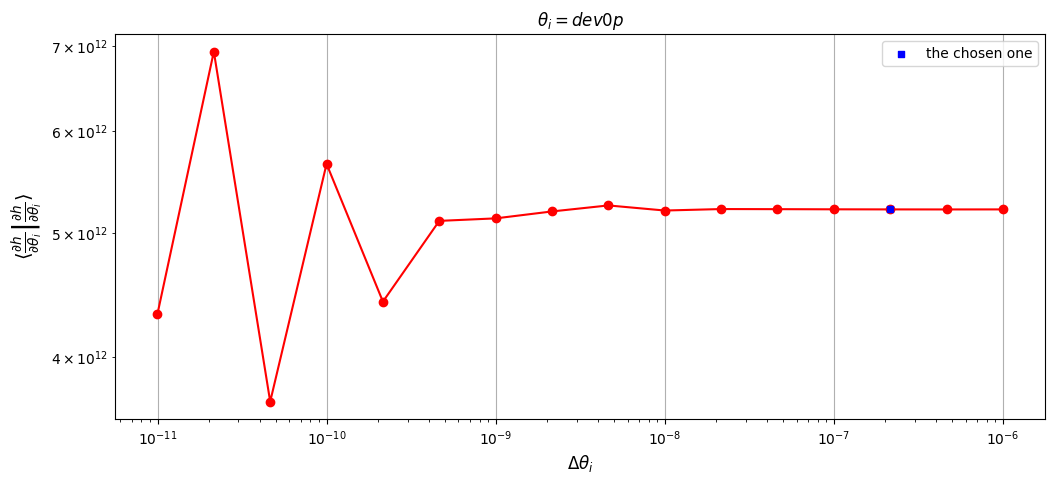

Gamma_ii for dev0e: 1419068543108.868
Gamma_ii for dev0e: 1419073034300.1277
Gamma_ii for dev0e: 1419116502000.4814
Gamma_ii for dev0e: 1418720653691.0413
Gamma_ii for dev0e: 1419191627043.5334
Gamma_ii for dev0e: 1418836791422.1897
Gamma_ii for dev0e: 1417467734515.7937
Gamma_ii for dev0e: 1422059918915.8909
Gamma_ii for dev0e: 1421162378891.0024
Gamma_ii for dev0e: 1431539749607.9243
Gamma_ii for dev0e: 1382308519822.9177
Gamma_ii for dev0e: 1474544012316.8076
Gamma_ii for dev0e: 1222717907686.3633
Gamma_ii for dev0e: 975173274720.2277
Gamma_ii for dev0e: 572233728708.1909
Gamma_ii for dev0e: 404696431714.38715
[np.float64(3.1648767549026357e-06), np.float64(3.063011408329393e-05), np.float64(0.00027901779565294924), np.float64(0.000331860295338214), np.float64(0.0002500891036156991), np.float64(0.0009658469629036496), np.float64(0.0032292481765452087), np.float64(0.0006315534651211489), np.float64(0.007249097148552159), np.float64(0.03561522560196143), np.float64(0.06255187483279609

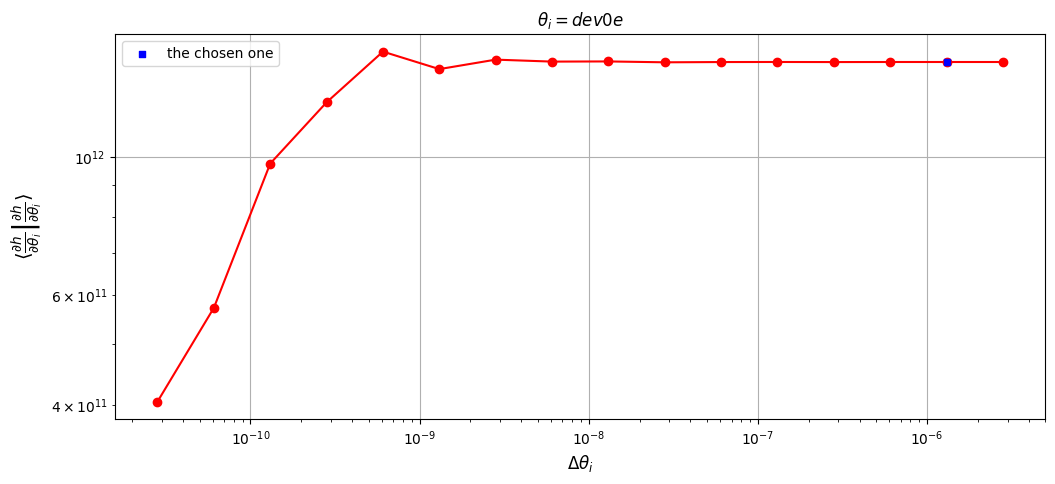

stable deltas: {'m1': 21.54892431143278, 'm2': 0.0004642299135951985, 'a': 4.456480929509136e-05, 'p0': 0.00015079419442139892, 'e0': 2.320617484081644e-05, 'qS': 0.0036455057172718333, 'phiS': 0.009996413559999997, 'Phi_phi0': 0.0, 'Phi_r0': 0.0, 'dev0p': 2.1460553588601173e-07, 'dev0e': 1.30825964372041e-06}
Time taken to compute stable deltas is 150.061753988266 seconds
calculating Fisher matrix...
Finished derivatives
Calculated Fisher is *atleast* positive-definite.
Time taken to compute FM is 9.988016843795776 seconds


In [9]:
param_names = ['m1','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0','dev0p','dev0e']
pars_list = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]

param_dict = {
    'm1': m1,
    'm2': m2,
    'a': a,
    'p0': p0,
    'e0': e0,
    'xI0': xI0,
    'dist': dist,
    'qS': qS,
    'phiS': phiS,
    'qK': qK,
    'phiK': phiK,
    'Phi_phi0': Phi_phi0,
    'Phi_theta0': Phi_theta0,
    'Phi_r0': Phi_r0
}


Fisher = sef(wave_params = param_dict,param_names=param_names, add_param_args=add_param_args,
            live_dangerously = False, stability_plot = True,der_order = der_order, Ndelta = Ndelta,return_derivatives=True
            )


In [17]:
def logmasstransform(Fisher, m1, index_of_m1 = 0):    
    J = np.eye(len(Fisher))
    J[index_of_m1,index_of_m1] = m1
    
    return J.T@Fisher@J
fisher_=logmasstransform(Fisher[-1], m1, index_of_m1 = 0)
cov=np.linalg.inv(fisher_)
std= np.sqrt(np.diag(cov))
params_truth_in = np.array([np.log(1e6), 10, 0.96, 7.0, 0.5, np.pi/4, 1.0,  0.9,0.4,0,0])

In [18]:
pd.DataFrame(fisher_)

,0,1,2,3,4,5,6,7,8,9,10
0,9.062093e+14,-1.019121e+13,6.690542e+13,1.909453e+14,9.826573e+14,-3.413243e+09,1.562644e+10,-4.097764e+09,-4.851480e+09,-6.656544e+13,-3.536963e+13
1,-1.019121e+13,1.204048e+11,-8.284830e+11,-2.158547e+12,-1.080043e+13,3.474781e+07,-1.590732e+08,4.171443e+07,4.684460e+07,7.918629e+11,4.124500e+11
2,6.690542e+13,-8.284830e+11,7.166649e+12,1.442928e+13,6.934292e+13,-2.377094e+08,1.088723e+09,-2.855524e+08,-2.150070e+08,-5.508605e+12,-2.778001e+12
3,1.909453e+14,-2.158547e+12,1.442928e+13,4.028312e+13,2.065821e+14,-7.171583e+08,3.283347e+09,-8.610090e+08,-1.000821e+09,-1.411316e+13,-7.477160e+12
4,9.826573e+14,-1.080043e+13,6.934292e+13,2.065821e+14,1.076401e+15,-3.862603e+09,1.768404e+10,-4.637330e+09,-5.597504e+09,-7.031479e+13,-3.771406e+13
5,-3.413243e+09,3.474781e+07,-2.377094e+08,-7.171583e+08,-3.862603e+09,1.976653e+04,-8.212555e+04,2.153533e+04,2.498833e+04,2.249560e+08,1.226007e+08
6,1.562644e+10,-1.590732e+08,1.088723e+09,3.283347e+09,1.768404e+10,-8.212555e+04,3.772251e+05,-9.862473e+04,-1.143912e+05,-1.029846e+09,-5.612580e+08
7,-4.097764e+09,4.171443e+07,-2.855524e+08,-8.610090e+08,-4.637330e+09,2.153533e+04,-9.862473e+04,2.586433e+04,2.999688e+04,2.700623e+08,1.471794e+08
8,-4.851480e+09,4.684460e+07,-2.150070e+08,-1.000821e+09,-5.597504e+09,2.498833e+04,-1.143912e+05,2.999688e+04,4.564285e+04,2.996001e+08,1.689585e+08
9,-6.656544e+13,7.918629e+11,-5.508605e+12,-1.411316e+13,-7.031479e+13,2.249560e+08,-1.029846e+09,2.700623e+08,2.996001e+08,5.214025e+12,2.706341e+12


In [19]:
from scipy.stats import chi2
def plot_confidence_ellipse(ax, mean, cov, i, j, levels=[0.90, 0.99]):
    """
    Plots 2D 90% and 99% confidence ellipses onto ax.
    mean: (D,) best-fit vector
    cov:  (D,D) covariance
    i,j: indices of parameters
    """
    # Extract 2x2 sub-covariance
    cov2 = cov[np.ix_([i, j], [i, j])]
    mean2 = mean[[i, j]]
    
    # Eigen decomposition
    eigvals, eigvecs = np.linalg.eigh(cov2)
    order = np.argsort(eigvals)[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]

    theta = np.linspace(0, 2*np.pi, 400)

    for p in levels:
        chi2_val = chi2.ppf(p, df=2)
        r1 = np.sqrt(eigvals[0] * chi2_val)
        r2 = np.sqrt(eigvals[1] * chi2_val)
        
        ellipse = np.vstack([r1*np.cos(theta), r2*np.sin(theta)])
        ellipse = eigvecs @ ellipse + mean2[:, None]

        ax.plot(ellipse[0], ellipse[1], label=f"{int(p*100)}%", lw=1)


# --------------------------------------------------------------------
# Main triangle plot function (WITH LEGEND)
# --------------------------------------------------------------------
def triangle_plot(best_fit, cov, param_truth=None, labels=None,levels=[0.90, 0.99]):
    D = len(best_fit)
    if labels is None:
        labels = [f"p{i}" for i in range(D)]

    fig, axes = plt.subplots(D, D, figsize=(2.2*D, 2.2*D))
    
    legend_ax = axes[-1, -1]  # bottom-right panel for legend only
    legend_handles = []       # store handles for legend

    for i in range(D):
        for j in range(D):

            ax = axes[i, j]

            if i < j:
                ax.axis("off")
                continue

            # ==========================
            # Diagonal panels
            # ==========================
            if i == j:
                sigma = np.sqrt(cov[i, i])
                x = np.linspace(best_fit[i] - 4*sigma,
                                best_fit[i] + 4*sigma, 300)
                y = np.exp(-0.5*((x - best_fit[i])/sigma)**2)

                ax.plot(x, y, lw=1.5)

                if param_truth is not None:
                    line_truth = ax.axvline(param_truth[i], color='red', linestyle='--', lw=1)

                ax.set_yticks([])
                ax.set_xlabel(labels[i])

            # ==========================
            # Off-diagonal panels
            # ==========================
            else:
                # Ellipses
                plot_confidence_ellipse(ax, best_fit, cov, j, i,levels=levels)

                # Best-fit point
                bestfit_handle = ax.scatter(best_fit[j], best_fit[i],
                                            color="black", s=12, label="Best-fit")

                # Truth point
                if param_truth is not None:
                    truth_handle = ax.scatter(param_truth[j], param_truth[i],
                                              color="red", marker="x", s=30,
                                              label="Param truth")

                ax.set_xlabel(labels[j])
                ax.set_ylabel(labels[i])

                # Collect handles only once (avoid duplicates)
                if i == D-1 and j == 0:
                    # ellipse handles
                    for item in ax.get_lines():
                        if "10%" in item.get_label() or "90%" in item.get_label():
                            legend_handles.append(item)
                    legend_handles.append(bestfit_handle)
                    if param_truth is not None:
                        legend_handles.append(truth_handle)

    # Add the legend to bottom-right subplot
    legend_ax.legend(handles=legend_handles, loc="upper right", fontsize=9)
    legend_ax.axis("off")  # hide this subplot except for legend

    plt.tight_layout()
    plt.show()


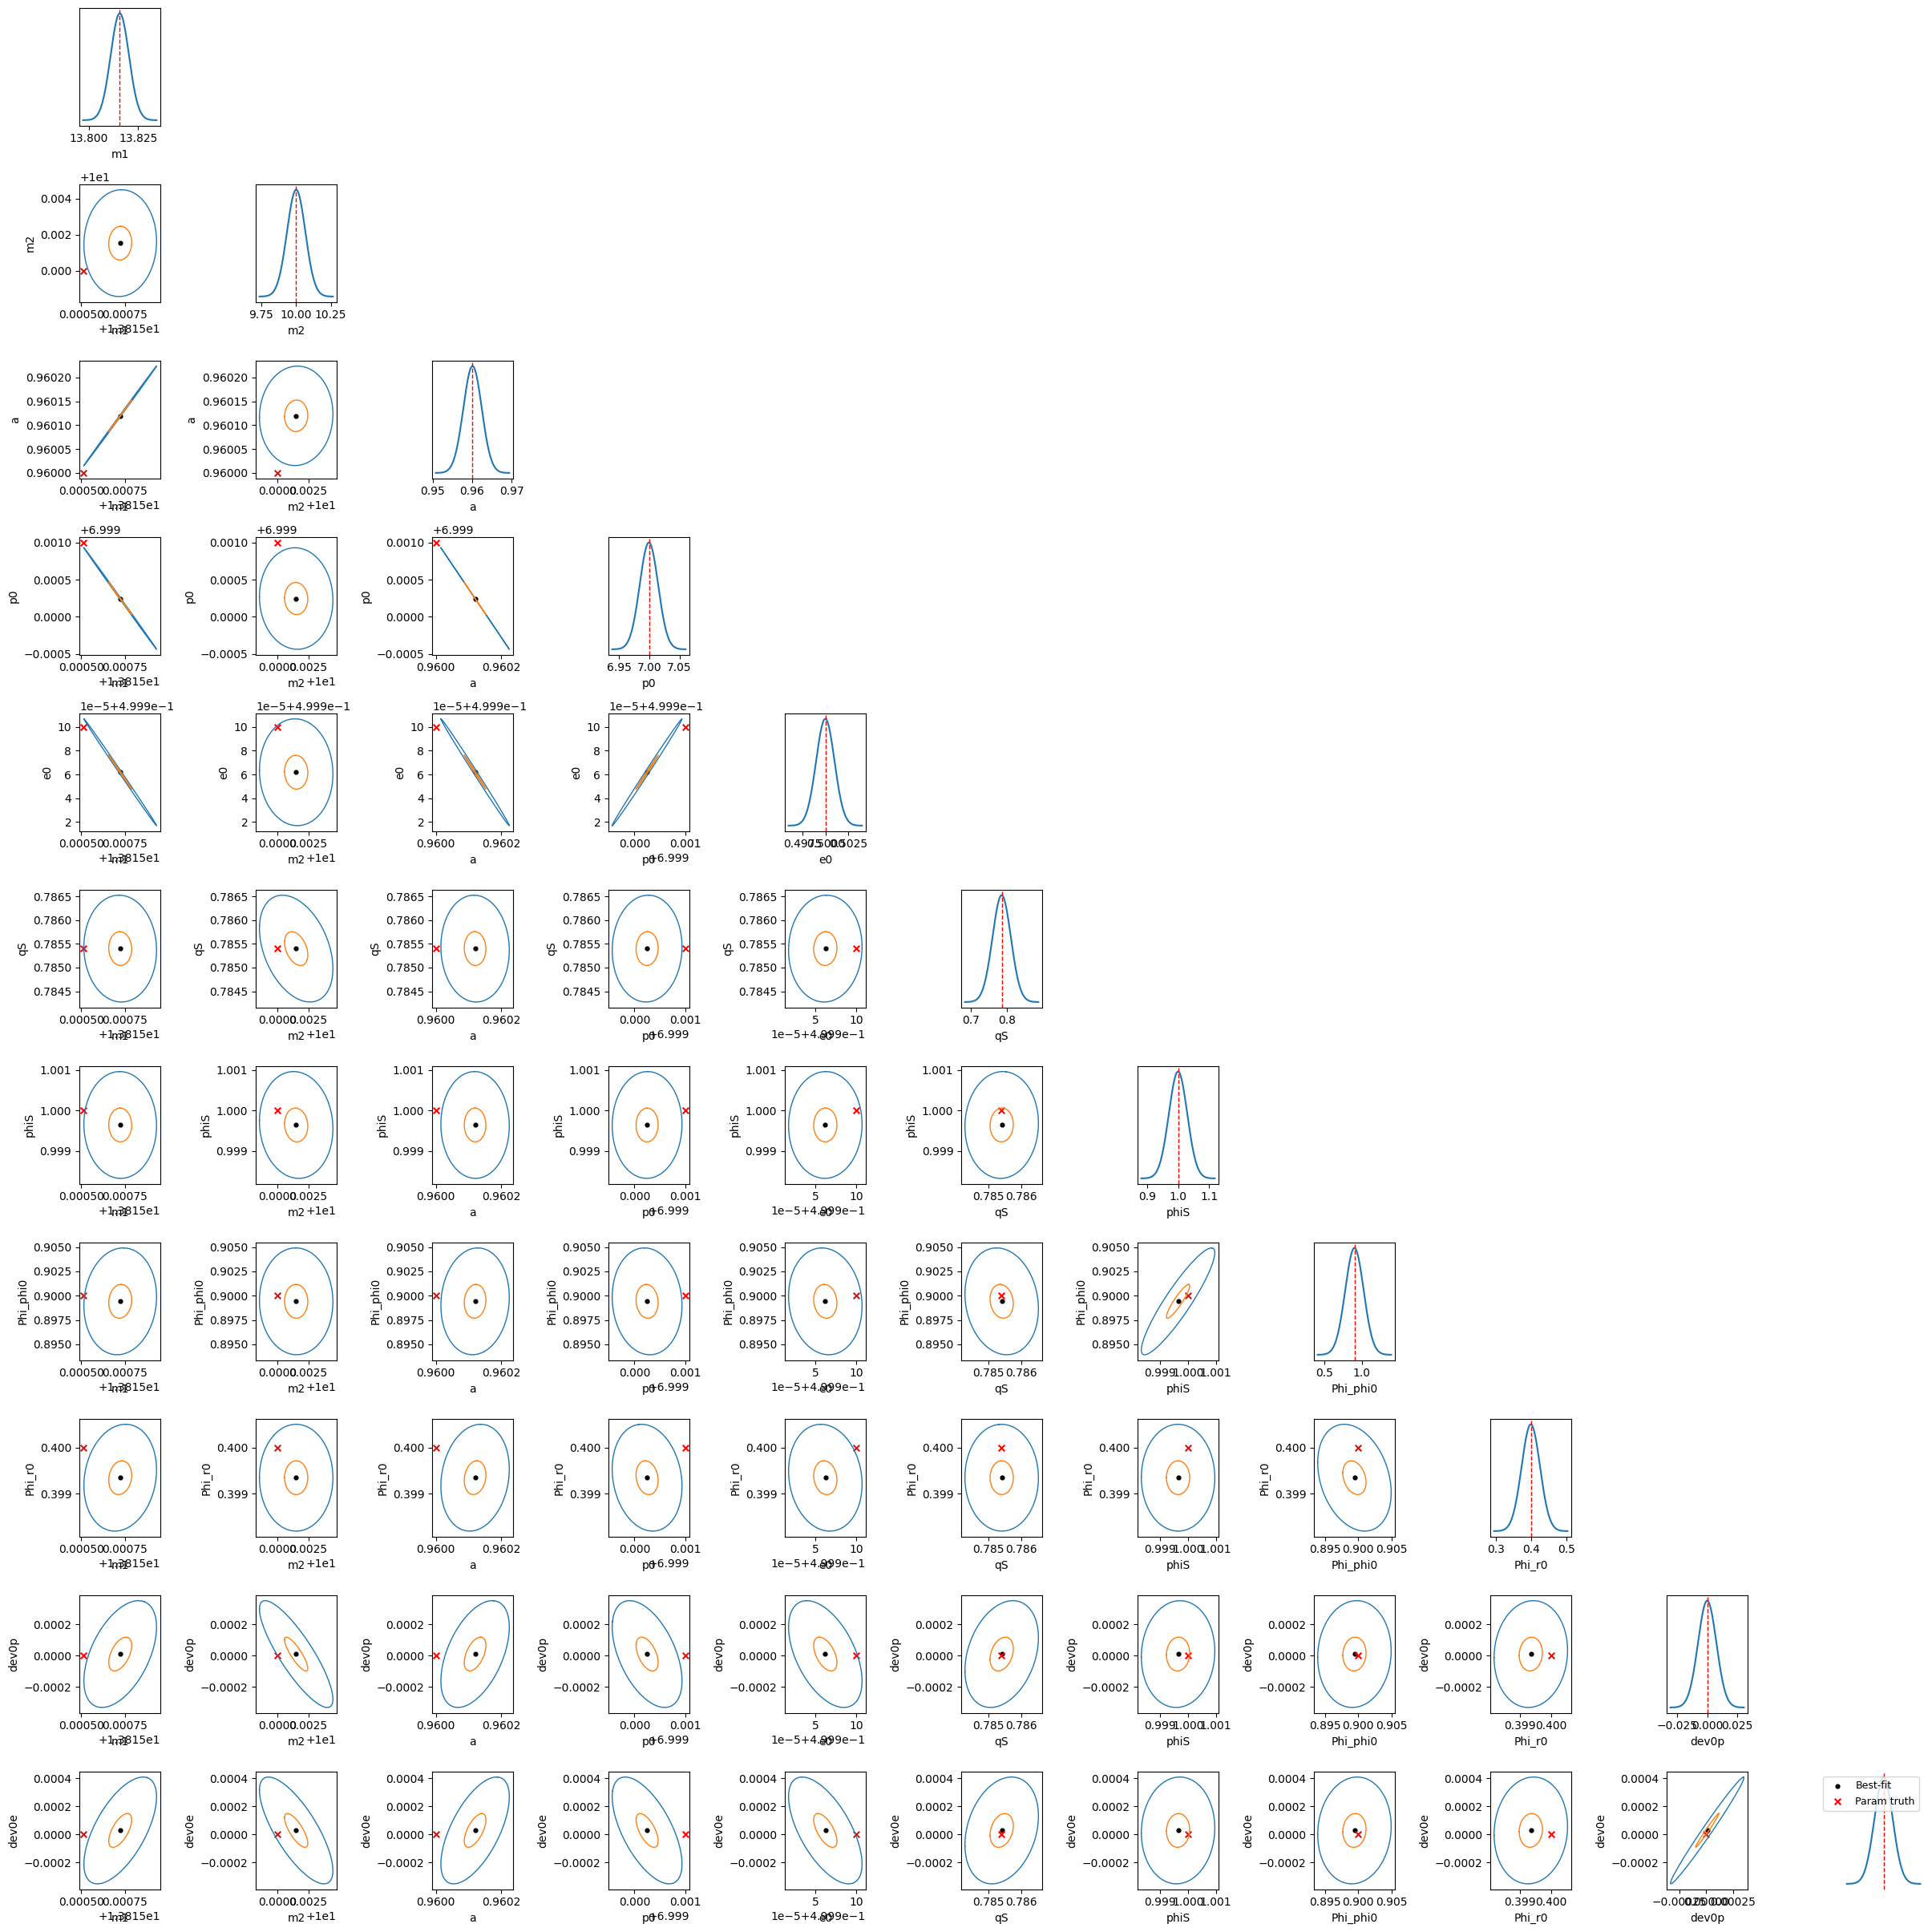

In [22]:
labels = param_names
triangle_plot(np.array(best_fit), cov, np.array(params_truth_in), labels,levels=[0.001, 0.0001])


In [57]:
# True waveform with 1PA order
m1_true = 1e6
m2_true = 10
a_true = 0.96 # 0.95
e0_true = 0.5 # 0.6 just spin first
xI0_true = 1.0
dist_true = 0.4
qS_true = xp.pi/4
phiS_true = 1.0
qK_true = 1 
phiK_true = xp.pi/3
Phi_phi0_true = 0.9
Phi_theta0_true =0.5
Phi_r0_true = 0.4
p0_true=7.0
chi2 = 0.0
dev_0_p_true=0.0
dev_0_e_true=0.0

evolve_1PA_true = True
evolve_primary = False
evolve_2PA = False
deviation_included=True

superkludge_wave = GenerateEMRIWaveform(SuperKludgeWaveform,\
                                    sum_kwargs=sum_kwargs,\
                                    return_list=True,
                                    mode_selector_kwargs=dict(mode_selection_threshold=1e-5),
                                    inspiral_kwargs=inspiral_kwargs,
                                    use_gpu=use_gpu)

add_args = [chi2, evolve_1PA_true, evolve_primary, evolve_2PA,deviation_included,dev_0_p_true,dev_0_e_true,dev_1_p,dev_1_e,dev_2_p,dev_2_e]
waveform_true = superkludge_wave(m1_true, m2_true, a_true, p0_true, e0_true, xI0_true, dist_true, qS_true, phiS_true, qK_true, phiK_true, Phi_phi0_true, Phi_theta0_true, Phi_r0_true, *add_args, dt=dt, T=T)
waveform_true= xp.asarray(waveform_true)
fisher_derivs = xp.array(Fisher[0])
fisher_exact = xp.array(Fisher[-1])




In [58]:
# baseline check - 0PA model at true parameters
evolve_1PA_approx = False
add_args = [chi2, evolve_1PA_approx, evolve_primary, evolve_2PA,deviation_included,dev_0_p_true,dev_0_e_true,dev_1_p,dev_1_e,dev_2_p,dev_2_e]
waveform_approx = superkludge_wave(m1_true, m2_true, a_true, p0_true, e0_true, xI0_true, dist_true, qS_true, phiS_true, qK_true, phiK_true, Phi_phi0_true, Phi_theta0_true, Phi_r0_true, *add_args, dt=dt, T=T)
waveform_approx= xp.asarray(waveform_approx)

In [59]:
# waveform at best fit parameters with 0PA calaculated during fisher calculation
waveform_best_fit=sef.waveform
waveform_best_fit= xp.asarray(waveform_best_fit)

# waveform analysis and p0 evolution 

In [60]:
from few.utils.utility import ( 
    get_mismatch, 
    get_m2_at_t, 
    get_p_at_t, 
    )

from few.utils.geodesic import (
    get_fundamental_frequencies,
    get_separatrix,
    get_kerr_geo_constants_of_motion,
    ELQ_to_pex,
    )
SK_traj = EMRIInspiral(func=SuperKludgeFlux)
#get_p_at_t may fail with SuperKludge, especially with lower eccentricities, so we use KerrEccEq to generate p0 
add_args = [chi2, evolve_1PA_true, evolve_primary, evolve_2PA,deviation_included,dev_0_p_true,dev_0_e_true,dev_1_p,dev_1_e,dev_2_p,dev_2_e]
p_sep = get_separatrix(a_true, e0_true, xI0_true)
p0_should = get_p_at_t(traj_module=SK_traj, t_out=0.5, traj_args=[m1_true, m2_true, a_true, e0_true, xI0_true, *add_args])
print('should take p0 around for for true waveform: ', p0_should+0.1)
print('separatrix p: ', p_sep)

should take p0 around for for true waveform:  5.801968276312249
separatrix p:  2.301471569030622


# P evolution is done considering true waveform (1PA)


[0.0, True, False, False, True, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


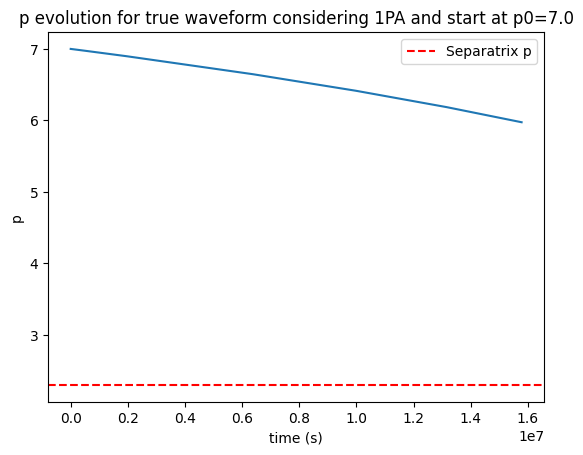

In [ ]:
from scipy.interpolate import CubicSpline
add_args = [chi2, evolve_1PA_true, evolve_primary, evolve_2PA,deviation_included,dev_0_p_true,dev_0_e_true,dev_1_p,dev_1_e,dev_2_p,dev_2_e]
print(add_args) 
t_evol, p_evol, e_evol, x2_evol, pp2_evol, pt2_evol, pr2_evol, _, _ = SK_traj(m1_true, m2_true, a_true, p0_true, e0_true, xI0_true, *add_args,
                                               Phi_phi0=Phi_phi0_true, Phi_theta0=Phi_theta0_true, Phi_r0=Phi_r0_true, T=T, dt=dt)
p_evolution = CubicSpline(t_evol, p_evol)(t_evol)
plt.plot(t_evol, p_evolution)
plt.title('p evolution for true waveform considering 1PA and start at p0=7.0')
plt.xlabel('time (s)')
plt.ylabel('p')
plt.axhline(p_sep, color='red', linestyle='--', label='Separatrix p')
plt.legend()
plt.show()

# Waveform Visualization

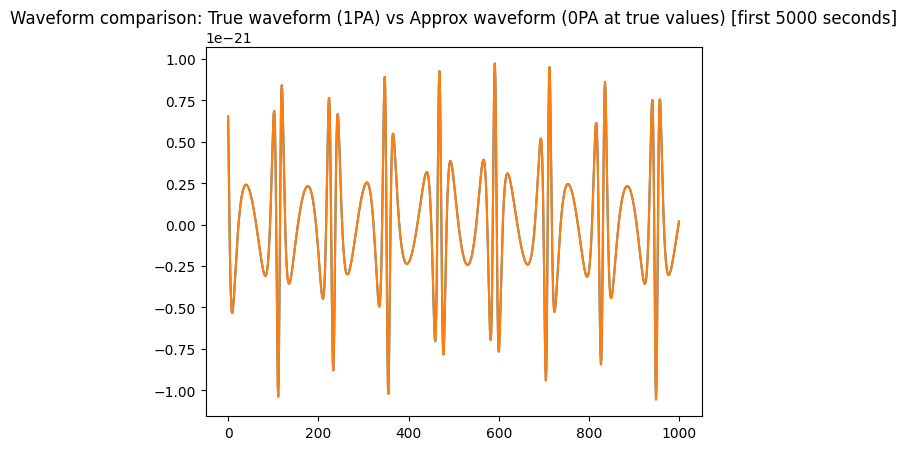

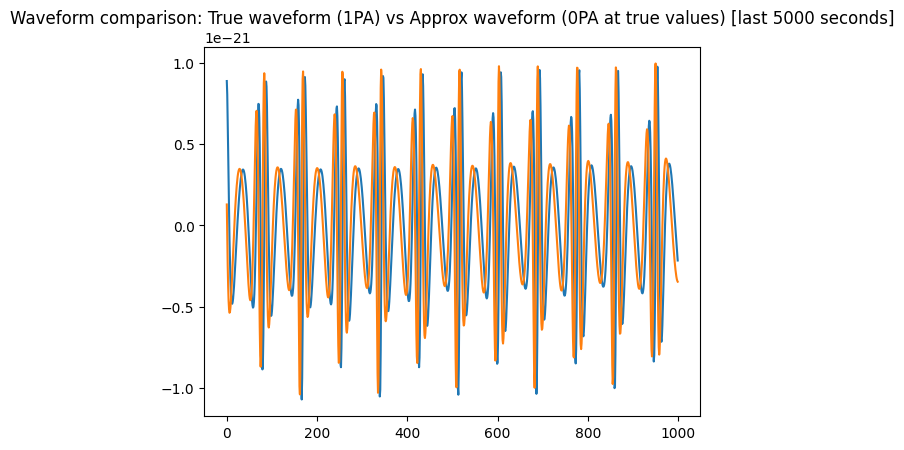

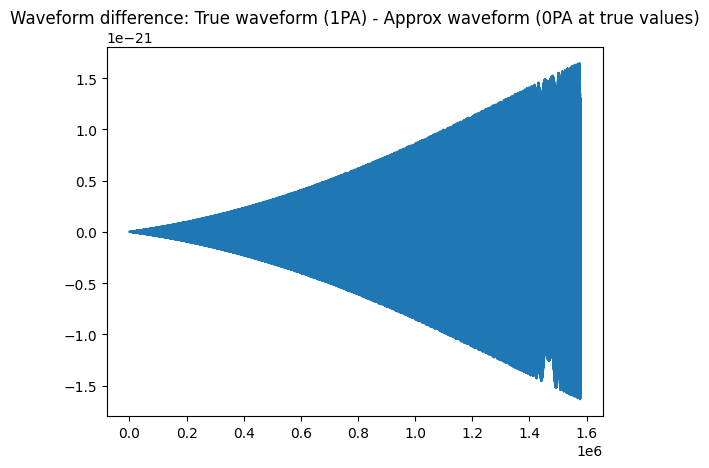

In [83]:
plt.plot(waveform_true[0][0:1000].get())
plt.plot(waveform_approx[0][0:1000].get())
plt.title('Waveform comparison: True waveform (1PA) vs Approx waveform (0PA at true values) [first 5000 seconds]')
plt.show()

plt.plot(waveform_true[0][-1000:].get())
plt.plot(waveform_approx[0][-1000:].get())
plt.title('Waveform comparison: True waveform (1PA) vs Approx waveform (0PA at true values) [last 5000 seconds]')
plt.show()
# waveform_approx
# waveform_best_fit
plt.plot((waveform_true[0]-waveform_approx[0]).get())
plt.title('Waveform difference: True waveform (1PA) - Approx waveform (0PA at true values)')
plt.show()

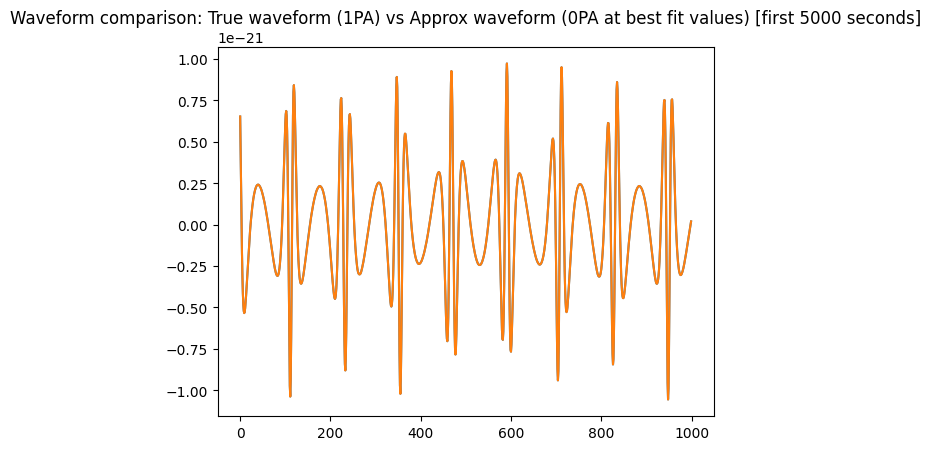

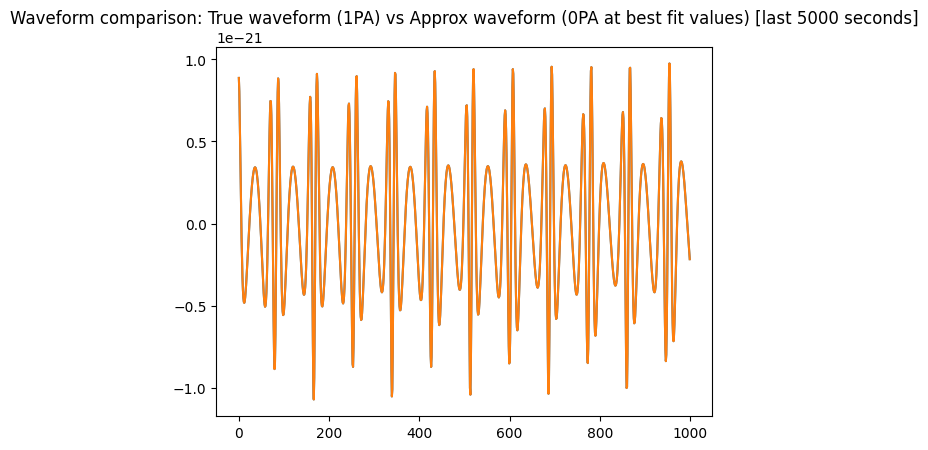

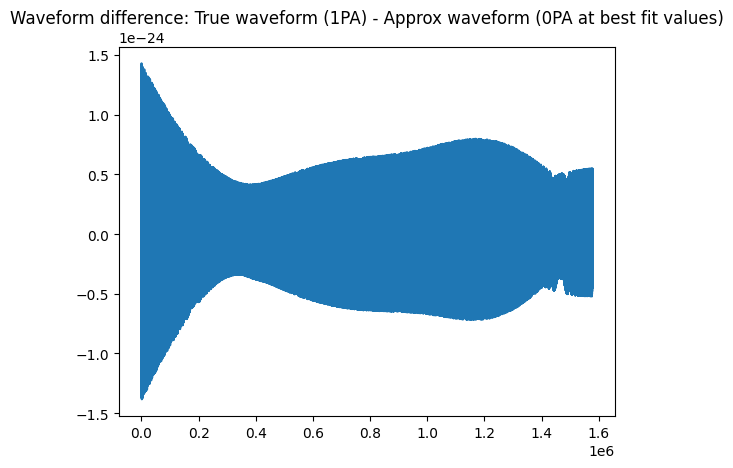

In [84]:
plt.plot(waveform_true[0][0:1000].get())
plt.plot(waveform_best_fit[0][0:1000].get())
plt.title('Waveform comparison: True waveform (1PA) vs Approx waveform (0PA at best fit values) [first 5000 seconds]')
plt.show()

plt.plot(waveform_true[0][-1000:].get())
plt.plot(waveform_best_fit[0][-1000:].get())
plt.title('Waveform comparison: True waveform (1PA) vs Approx waveform (0PA at best fit values) [last 5000 seconds]')
plt.show()
# waveform_approx
# waveform_best_fit
plt.plot((waveform_true[0]-waveform_best_fit[0]).get())
plt.title('Waveform difference: True waveform (1PA) - Approx waveform (0PA at best fit values)')
plt.show()

# Overlap and mismatch

In [85]:
PSD=generate_PSD(waveform_true,dt,use_gpu=use_gpu,
                noise_PSD=get_sensitivity,
                noise_kwargs={'sens_fn':CornishLISASens,'return_type':'PSD'},
                channels=["A","E"])
diff_inner_bf=inner_product(waveform_best_fit,waveform_true,PSD,dt,use_gpu=use_gpu)
norm_true=np.sqrt(inner_product(waveform_true,waveform_true,PSD,dt,use_gpu=use_gpu))
norm_bf=np.sqrt(inner_product(waveform_best_fit,waveform_best_fit,PSD,dt,use_gpu=use_gpu))
overlap_bf=diff_inner_bf/((norm_true)*norm_bf)
print("overlap between best fit point and true waveform:", overlap_bf)
print("mismatch between best fit point and true waveform:", 1-overlap_bf)

norm_approx=np.sqrt(inner_product(waveform_approx,waveform_approx,PSD,dt,use_gpu=use_gpu))
diff_inner_approx=inner_product(waveform_approx,waveform_true,PSD,dt,use_gpu=use_gpu)
overlap_approx=diff_inner_approx/((norm_true)*norm_approx)
print("overlap between approximate waveform and true waveform (both at true points)", overlap_approx)
print("mismatch between approximate waveform and true waveform (both at true points):", 1-overlap_approx)

overlap between best fit point and true waveform: 0.9999999055153056
mismatch between best fit point and true waveform: 9.44846944017641e-08
overlap between approximate waveform and true waveform (both at true points) 0.7101551567036656
mismatch between approximate waveform and true waveform (both at true points): 0.2898448432963344


# Table true vs bias

In [87]:
best_fit

[13.815723,
 10.0015303,
 0.960119711,
 6.99924649,
 0.499961881,
 0.785400398,
 0.999641356,
 0.899421437,
 0.399348944,
 9.96110659e-06,
 2.81855996e-05]

In [90]:
import pandas as pd
best_fit[0] = np.exp(13.815723)
truue_param=[m1_true,m2_true,a_true,p0_true,e0_true,qS_true,phiS_true,Phi_phi0_true,Phi_r0_true,dev_0_p_true,dev_0_e_true]
df = pd.DataFrame({'Best Fit': best_fit, 'True Param': truue_param}, index=param_names)
print(df)

              Best Fit      True Param
m1        1.000212e+06  1000000.000000
m2        1.000153e+01       10.000000
a         9.601197e-01        0.960000
p0        6.999246e+00        7.000000
e0        4.999619e-01        0.500000
qS        7.854004e-01        0.785398
phiS      9.996414e-01        1.000000
Phi_phi0  8.994214e-01        0.900000
Phi_r0    3.993489e-01        0.400000
dev0p     9.961107e-06        0.000000
dev0e     2.818560e-05        0.000000


In [91]:
# #Orthoganal check between derivative and exact fisher matrices
# PSD=generate_PSD(waveform_true,dt,use_gpu=use_gpu,
#                 noise_PSD=get_sensitivity,
#                 noise_kwargs={'sens_fn':CornishLISASens,'return_type':'PSD'},
#                 channels=["A","E"])
# inner_val = []
# for i in range(fisher_derivs.shape[0]):
#     temp_deriv = inner_product(fisher_derivs[i],waveform_true-sef.waveform, PSD=PSD, dt=dt,use_gpu=use_gpu)
#     inner_val.append(temp_deriv)
